```markdown
# Python Data Analysis Assignment

## Student Details:
- **Name**: YOUR_NAME
- **Register Number**: YOUR_REG_NO
- **Class**: B.Tech CSE

This notebook demonstrates data analysis for a hypothetical XYZ Company, including dataset creation, calculations, visualizations, and report generation.
```

```markdown
## 1. Install Required Libraries
```

In [1]:
# Install reportlab for PDF generation
!pip install reportlab

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 12.0 MB/s eta 0:00:00


```markdown
## 2. Import Libraries
```

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from reportlab.lib.pagesizes import letter
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Image, Table, TableStyle
from reportlab.lib.styles import getSampleStyleSheet
from reportlab.lib import colors
from reportlab.lib.units import inch # Import inch for spacing calculations
import os

```markdown
## 3. Create Dataset for XYZ Company

This section generates a dataset for 50 products, including `Product_ID`, `Product_Name`, `Unit_Price`, and monthly sales figures for January to December.
```

In [22]:
# Set a seed for reproducibility
np.random.seed(42)

# Number of products
num_products = 50

# Generate Product_ID
product_ids = [f'P{i:03d}' for i in range(1, num_products + 1)]

# Generate Product_Name
product_names = [f'Product_{chr(65 + i // 26)}{chr(65 + i % 26)}' for i in range(num_products)]

# Generate Unit_Price (random prices between 10 and 500)
unit_prices = np.random.randint(10, 501, num_products)

# Generate Monthly Sales (random sales quantity for each month)
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly_sales_data = {}
for month in months:
    monthly_sales_data[f'Sales_{month}'] = np.random.randint(50, 1000, num_products)

# Create DataFrame
data = {
    'Product_ID': product_ids,
    'Product_Name': product_names,
    'Unit_Price': unit_prices,
    **monthly_sales_data
}
df = pd.DataFrame(data)

print("Dataset created successfully!")

Dataset created successfully!


In [23]:
# Display the first 5 rows of the dataset
display(df.head())

,Product_ID,Product_Name,Unit_Price,Sales_Jan,Sales_Feb,Sales_Mar,Sales_Apr,Sales_May,Sales_Jun,Sales_Jul,Sales_Aug,Sales_Sep,Sales_Oct,Sales_Nov,Sales_Dec
0,P001,Product_AA,112,925,319,250,220,721,659,303,945,86,457,933,910
1,P002,Product_AB,445,616,912,889,590,657,247,701,441,329,574,399,296
2,P003,Product_AC,358,293,865,829,85,521,956,502,184,398,877,96,125
3,P004,Product_AD,280,881,320,979,574,282,560,86,244,546,555,916,203
4,P005,Product_AE,116,554,505,82,209,741,801,209,450,351,952,872,705


```markdown
## 4. Save the Dataset

The generated dataset is saved as `xyz_sales.csv`.
```

In [24]:
# Save the DataFrame to a CSV file
df.to_csv('xyz_sales.csv', index=False)
print("Dataset saved as 'xyz_sales.csv'.")

Dataset saved as 'xyz_sales.csv'.


```markdown
## 5. Data Analysis and Calculations

This section performs various calculations:
- Total Sales Amount for each product.
- Monthly Income for Jan-Dec.
- Identifies the Top 5 Products based on Total Sales Amount.
- Identifies the Top 3 Months based on Monthly Income.
```

In [6]:
# Calculate Total Sales Amount for each product
# Multiply Unit_Price by monthly sales for each month and sum them up
for month in months:
    df[f'Revenue_{month}'] = df['Unit_Price'] * df[f'Sales_{month}']

df['Total_Sales_Amount'] = df[[f'Revenue_{month}' for month in months]].sum(axis=1)

# Calculate Monthly Income for Jan-Dec
monthly_income = {month: df[f'Revenue_{month}'].sum() for month in months}
monthly_income_df = pd.DataFrame(list(monthly_income.items()), columns=['Month', 'Income'])

# Top 5 Products based on Total Sales Amount
top_5_products = df.sort_values(by='Total_Sales_Amount', ascending=False).head(5)

# Top 3 Months based on Monthly Income
top_3_months = monthly_income_df.sort_values(by='Income', ascending=False).head(3)

print("Calculations completed successfully!")

print("\nTop 5 Products:")
display(top_5_products[['Product_Name', 'Total_Sales_Amount']])

print("\nTop 3 Months:")
display(top_3_months)

Calculations completed successfully!

Top 5 Products:


,Product_Name,Total_Sales_Amount
28,Product_BC,3802029
48,Product_BW,3788785
13,Product_AN,3296124
38,Product_BM,3115024
43,Product_BR,3101461



Top 3 Months:


,Month,Income
2,Mar,8487457
5,Jun,8099941
10,Nov,7729088


```markdown
## 6. Generate Charts

This section generates and saves four types of charts:
- Bar Chart for Top 5 Products.
- Bar Chart for Monthly Income.
- Pie Chart for Product Sales Distribution.
- Pie Chart for Monthly Income Distribution.
```

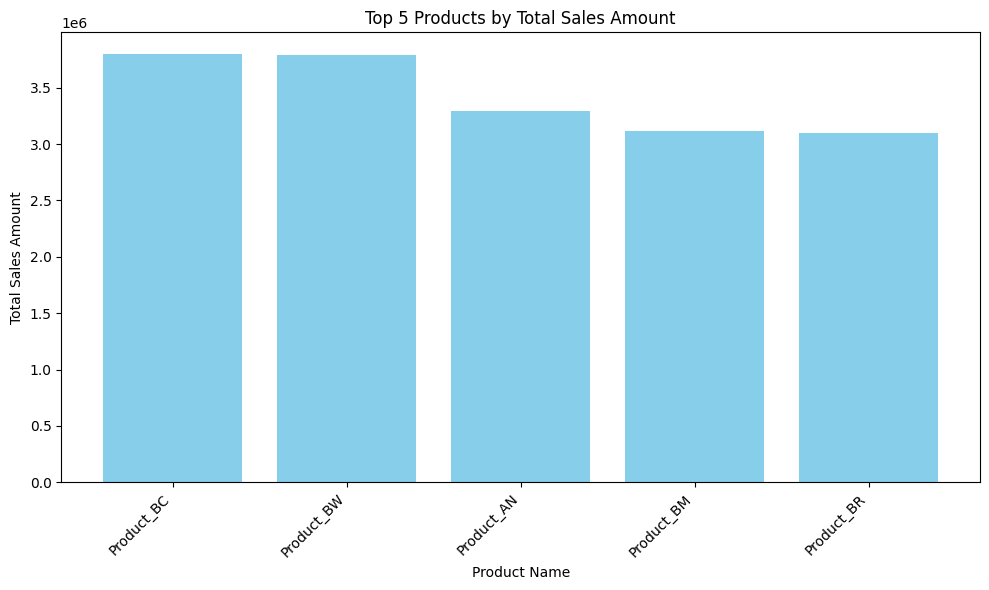

Saved 'top_5_products_bar_chart.png'


In [7]:
# Bar Chart for Top 5 Products
plt.figure(figsize=(10, 6))
plt.bar(top_5_products['Product_Name'], top_5_products['Total_Sales_Amount'], color='skyblue')
plt.xlabel('Product Name')
plt.ylabel('Total Sales Amount')
plt.title('Top 5 Products by Total Sales Amount')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('top_5_products_bar_chart.png')
plt.show()
print("Saved 'top_5_products_bar_chart.png'")

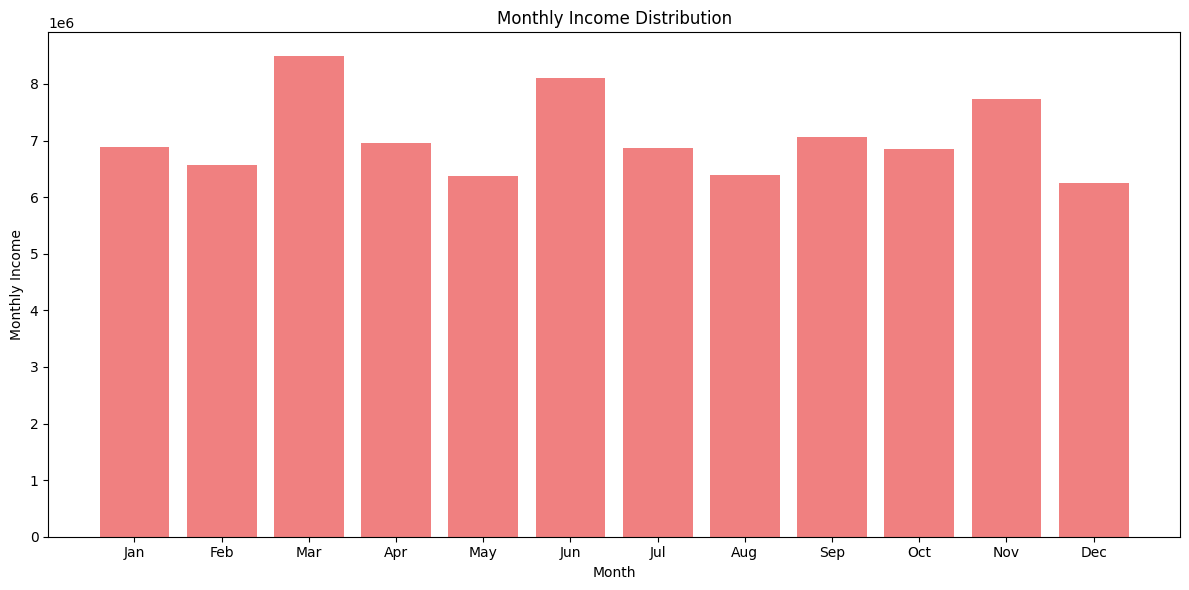

Saved 'monthly_income_bar_chart.png'


In [8]:
# Bar Chart for Monthly Income
plt.figure(figsize=(12, 6))
plt.bar(monthly_income_df['Month'], monthly_income_df['Income'], color='lightcoral')
plt.xlabel('Month')
plt.ylabel('Monthly Income')
plt.title('Monthly Income Distribution')
plt.tight_layout()
plt.savefig('monthly_income_bar_chart.png')
plt.show()
print("Saved 'monthly_income_bar_chart.png'")

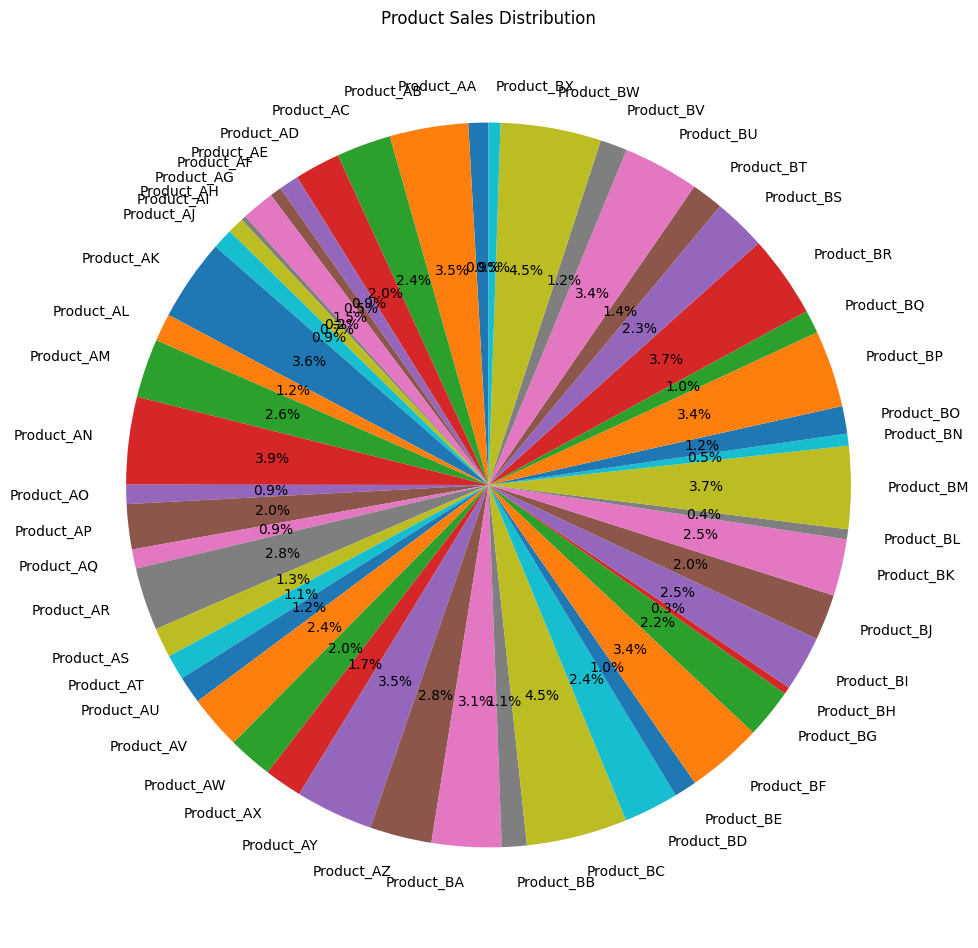

Saved 'product_sales_pie_chart.png'


In [9]:
# Pie Chart for Product Sales Distribution (using a sample of top products for clarity if too many products)
# For all 50 products, a pie chart might be too crowded, so we'll show a significant portion or adapt.
# Let's consider the top 10 products for a more readable pie chart, or a general distribution for all.
# For the assignment, we'll use all product total sales amounts.

plt.figure(figsize=(10, 10))
plt.pie(df['Total_Sales_Amount'], labels=df['Product_Name'], autopct='%1.1f%%', startangle=90)
plt.title('Product Sales Distribution')
plt.tight_layout()
plt.savefig('product_sales_pie_chart.png')
plt.show()
print("Saved 'product_sales_pie_chart.png'")

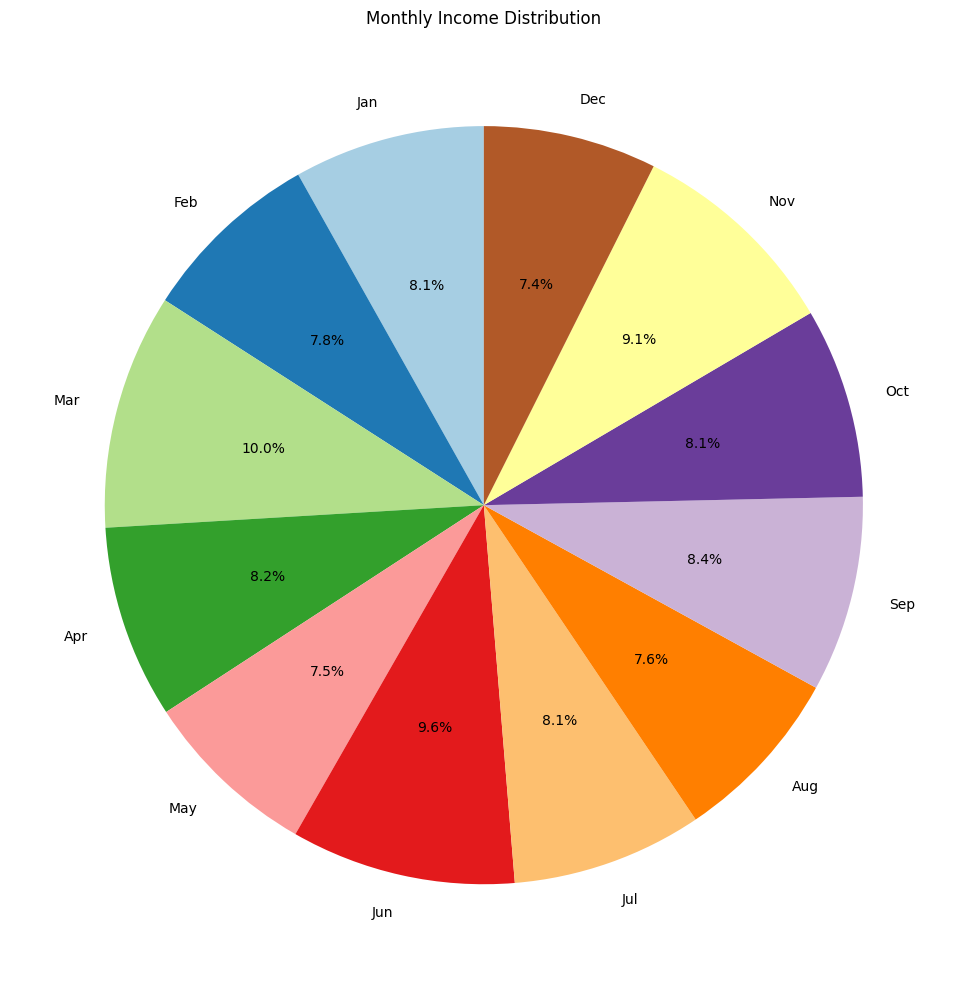

Saved 'monthly_income_pie_chart.png'


In [10]:
# Pie Chart for Monthly Income Distribution
plt.figure(figsize=(10, 10))
plt.pie(monthly_income_df['Income'], labels=monthly_income_df['Month'], autopct='%1.1f%%', startangle=90, colors=plt.cm.Paired.colors)
plt.title('Monthly Income Distribution')
plt.tight_layout()
plt.savefig('monthly_income_pie_chart.png')
plt.show()
print("Saved 'monthly_income_pie_chart.png'")

```markdown
## 7. Generate Professional PDF Report

This section uses ReportLab to create a PDF report summarizing the analysis, including student details, dataset summary, top products/months, analysis, and embedded charts.
```

In [27]:
def generate_pdf_report(filename="sales_report.pdf", student_name="YOUR_NAME", register_no="YOUR_REG_NO", student_class="B.Tech CSE"):
    doc = SimpleDocTemplate(filename, pagesize=letter)
    styles = getSampleStyleSheet()
    story = []

    # Title
    story.append(Paragraph("XYZ Company Sales Analysis Report", styles['h1']))
    story.append(Spacer(1, 0.2 * inch))

    # Student Details
    story.append(Paragraph("Student Details:", styles['h2']))
    story.append(Paragraph(f"Name: {student_name}", styles['Normal']))
    story.append(Paragraph(f"Register Number: {register_no}", styles['Normal']))
    story.append(Paragraph(f"Class: {student_class}", styles['Normal']))
    story.append(Spacer(1, 0.4 * inch))

    # Dataset Summary
    story.append(Paragraph("Dataset Summary:", styles['h2']))
    story.append(Paragraph(f"Total Products: {len(df)}", styles['Normal']))
    story.append(Paragraph(f"Dataset Head:", styles['Normal']))

    # Convert DataFrame head to a list of lists for ReportLab Table
    df_head_data = [df.columns.tolist()] + df.head().values.tolist()
    table = Table(df_head_data)
    table.setStyle(TableStyle([
        ('BACKGROUND', (0, 0), (-1, 0), colors.grey),
        ('TEXTCOLOR', (0, 0), (-1, 0), colors.whitesmoke),
        ('ALIGN', (0, 0), (-1, -1), 'CENTER'),
        ('FONTNAME', (0, 0), (-1, 0), 'Helvetica-Bold'),
        ('BOTTOMPADDING', (0, 0), (-1, 0), 12),
        ('BACKGROUND', (0, 1), (-1, -1), colors.beige),
        ('GRID', (0, 0), (-1, -1), 1, colors.black)
    ]))
    story.append(table)
    story.append(Spacer(1, 0.4 * inch))

    # Top 5 Products
    story.append(Paragraph("Top 5 Products by Total Sales Amount:", styles['h2']))
    top_5_data = [top_5_products.columns.tolist()] + top_5_products[['Product_Name', 'Total_Sales_Amount']].values.tolist()
    table_top5 = Table(top_5_data)
    table_top5.setStyle(TableStyle([
        ('BACKGROUND', (0, 0), (-1, 0), colors.grey),
        ('TEXTCOLOR', (0, 0), (-1, 0), colors.whitesmoke),
        ('ALIGN', (0, 0), (-1, -1), 'CENTER'),
        ('FONTNAME', (0, 0), (-1, 0), 'Helvetica-Bold'),
        ('BOTTOMPADDING', (0, 0), (-1, 0), 12),
        ('BACKGROUND', (0, 1), (-1, -1), colors.beige),
        ('GRID', (0, 0), (-1, -1), 1, colors.black)
    ]))
    story.append(table_top5)
    story.append(Spacer(1, 0.4 * inch))

    # Top 3 Months
    story.append(Paragraph("Top 3 Months by Monthly Income:", styles['h2']))
    top_3_data = [top_3_months.columns.tolist()] + top_3_months.values.tolist()
    table_top3 = Table(top_3_data)
    table_top3.setStyle(TableStyle([
        ('BACKGROUND', (0, 0), (-1, 0), colors.grey),
        ('TEXTCOLOR', (0, 0), (-1, 0), colors.whitesmoke),
        ('ALIGN', (0, 0), (-1, -1), 'CENTER'),
        ('FONTNAME', (0, 0), (-1, 0), 'Helvetica-Bold'),
        ('BOTTOMPADDING', (0, 0), (-1, 0), 12),
        ('BACKGROUND', (0, 1), (-1, -1), colors.beige),
        ('GRID', (0, 0), (-1, -1), 1, colors.black)
    ]))
    story.append(table_top3)
    story.append(Spacer(1, 0.4 * inch))

    # Analysis
    story.append(Paragraph("Analysis:", styles['h2']))
    story.append(Paragraph(
        "The analysis reveals key insights into product performance and seasonal sales trends. "
        "Product sales distribution highlights top-performing products, while monthly income "
        "patterns indicate periods of high and low revenue. These insights can be used for "
        "inventory management, marketing strategies, and sales forecasting.", styles['Normal']
    ))
    story.append(Spacer(1, 0.4 * inch))

    # Charts
    story.append(Paragraph("Charts:", styles['h2']))

    chart_files = [
        'top_5_products_bar_chart.png',
        'monthly_income_bar_chart.png',
        'product_sales_pie_chart.png',
        'monthly_income_pie_chart.png'
    ]

    for chart_file in chart_files:
        if os.path.exists(chart_file):
            img = Image(chart_file, width=400, height=300)
            story.append(img)
            story.append(Spacer(1, 0.2 * inch))
        else:
            story.append(Paragraph(f"Chart not found: {chart_file}", styles['Normal']))

    doc.build(story)
    print(f"PDF report '{filename}' generated successfully.")

# Call the function to generate the report
generate_pdf_report(student_name="YOUR_NAME", register_no="YOUR_REG_NO", student_class="B.Tech CSE")

PDF report 'sales_report.pdf' generated successfully.


```markdown
## 8. Download Files

Use the following commands to download the generated CSV dataset and PDF report.
```

In [28]:
from google.colab import files

# Download the generated CSV file
files.download('xyz_sales.csv')

# Download the generated PDF report
files.download('sales_report.pdf')

# Clean up chart images after report generation (optional)
# Uncomment the following lines if you want to remove the chart images
# import os
# for chart_file in [
#     'top_5_products_bar_chart.png',
#     'monthly_income_bar_chart.png',
#     'product_sales_pie_chart.png',
#     'monthly_income_pie_chart.png'
# ]:
#     if os.path.exists(chart_file):
#         os.remove(chart_file)
# print("Cleaned up chart image files.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>